# Lab #01 — Image Geometric Transformations (2D)

**Course:** Computer Vision Lab  

## 1. Background: What is a Geometric Transformation?

A **geometric transformation** changes the spatial arrangement of an image. Instead of primarily changing the intensity/color value of a pixel, it changes **where that pixel appears** in the output image.

Geometric transformations are fundamental in computer vision because images may need to be:

- aligned with another image,
- resized,
- rotated,
- corrected for viewpoint,
- reflected or flipped,
- warped into a new coordinate system,
- prepared for object detection, recognition or tracking.

describes geometric transformations as operations that change image geometry while preserving the actual pixel values, with the important idea that **the positions of pixel values change**.

Examples covered in this lab are:

| Transformation | Main effect |
|---|---|
| Translation | Moves the image |
| Rotation | Changes orientation |
| Scaling | Enlarges or shrinks |
| Reflection | Flips the image |
| Shearing | Slants/distorts the image |
| Affine | Combines linear 2D transformations |
| Perspective | Models viewpoint-related deformation |

## 2. Coordinate Representation

A point in a 2D image is represented as

\[
P = (x,y)
\]

where:

- \(x\) represents horizontal position,
- \(y\) represents vertical position.

For an image, the coordinate system is normally measured in pixels. In OpenCV images, the array indexing convention is:

```text
image[y, x]
```

So the mathematical point \((x,y)\) corresponds to the NumPy location `[y, x]`.

### Important distinction

- **Point:** `(x, y)`
- **Pixel access:** `image[y, x]`

This distinction is one of the most common sources of mistakes in computer vision programming.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.4.6


## 3. Load a Real Image: Lena

Image shape (H, W, C): (6000, 4000, 3)
Height: 6000
Width: 4000
Channels: 3


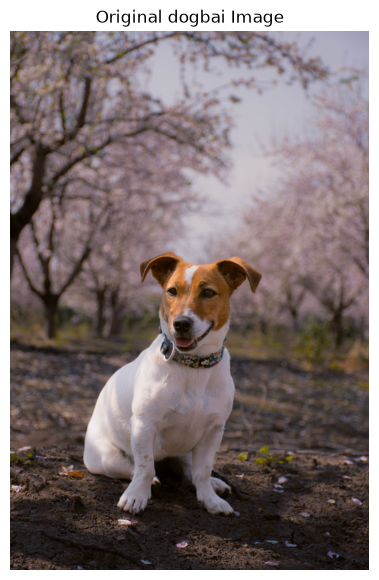

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve
# --------------------------------------------------
# Load image
# --------------------------------------------------
image_path = Path("imagess.jpg")
img = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
if img is None:
    raise FileNotFoundError("Could not load")
# Image dimensions
H, W = img.shape[:2]
#print("OpenCV version:", cv2.__version__)
print("Image shape (H, W, C):", img.shape)
print("Height:", H)
print("Width:", W)
print("Channels:", img.shape[2])

# Display correctly with Matplotlib
plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original dogbai Image")
plt.axis("off")
plt.show()


### Why use a real image?

Synthetic shapes are excellent for introducing matrices, but a real image lets you observe how transformations affect:

- facial features and orientation,
- edges and texture,
- asymmetric structures,
- interpolation artifacts,
- image cropping and empty border regions.

**Observation rule:** For every experiment, compare the transformed image with the original and describe exactly which geometric property changed.

## 4. Translation

Translation moves every point by a fixed amount.


For OpenCV's affine transformation function, the corresponding 2×3 matrix is:
$$
M =
\begin{bmatrix}
1&0&d_x\\
0&1&d_y
\end{bmatrix}
$$
The supplied lab uses `cv2.warpAffine()` for this operation.

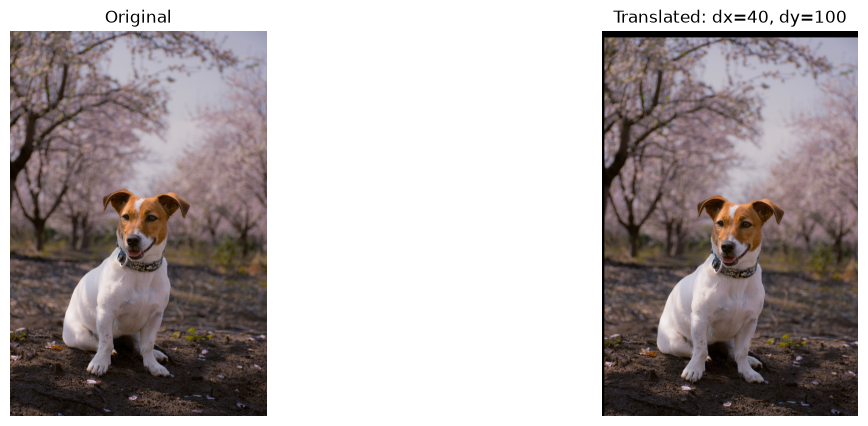

In [6]:
dx, dy = 40, 100

M_translation = np.float32([
    [1, 0, dx],
    [0, 1, dy]
])

translated = cv2.warpAffine(img, M_translation, (W, H), borderValue=(255, 255, 255))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Translated: dx={dx}, dy={dy}")

for a in ax:
    a.axis("off")
plt.show()

### Experiment A1

Change `dx` and `dy` and observe the direction of motion.

Try:

- `(100, 0)`
- `(0, 100)`
- `(-100, 0)`
- `(100, -80)`

**Question:** Why does a positive `dy` move the image downward in an OpenCV image?

In [7]:
# code here

## 5. Rotation

Rotation changes the orientation of points around a chosen center.

For rotation about the origin by angle \(\theta\):
$$
x' = x\cos\theta-y\sin\theta
                y' = x\sin\theta+y\cos\theta
$$

The rotation matrix is:

\[
R=
\begin{bmatrix}
\cos\theta&-\sin\theta\\
\sin\theta&\cos\theta
\end{bmatrix}
\]

In real images, we usually rotate around the **image center** rather than the origin.

OpenCV provides:

```python
cv2.getRotationMatrix2D(center, angle, scale)
```

which produces a 2×3 affine matrix that can be passed to `cv2.warpAffine()`.

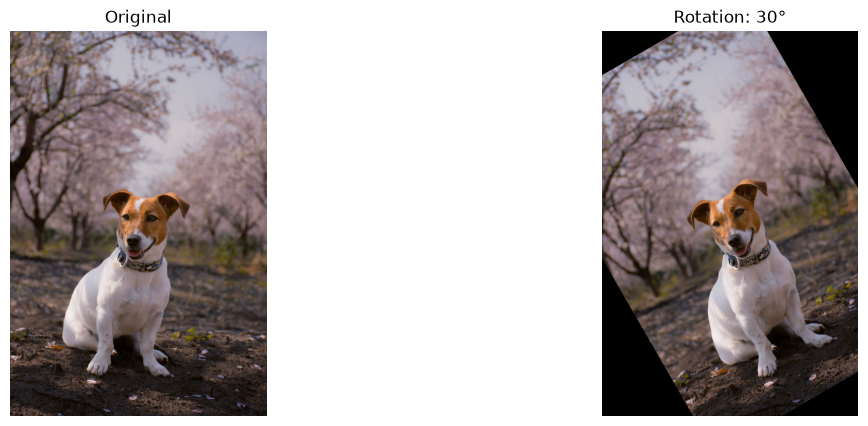

Rotation matrix:
[[ 8.66025404e-01  5.00000000e-01 -1.23205081e+03]
 [-5.00000000e-01  8.66025404e-01  1.40192379e+03]]


In [8]:
center = (W // 2, H // 2) # centre
angle = 30 #angle
rotation_scale = 1.0 #no scalling

M_rotation = cv2.getRotationMatrix2D(center, angle, rotation_scale)
rotated = cv2.warpAffine(img, M_rotation, (W, H))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Rotation: {angle}°")

for a in ax:
    a.axis("off")
plt.show()

print("Rotation matrix:")
print(M_rotation)

### Experiment B1 — Rotation Around a Different Point

Change the rotation center.

```python
center = (100, 100)
```

Then rotate by:

- +45°
- +90°
- -30°

In [9]:
#code here
center = (100, 100)
for angle in [45, 90, -30]:
    M_rotation = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )
    rotated = cv2.warpAffine(
        img,
        M_rotation,
        (W, H)
    )
    plt.figure(figsize=(7, 5))
    plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Center={center}, Rotation={angle}°")
    plt.axis("off")
    plt.show()

## 6. Scaling / Resizing

Scaling changes the spatial size of an image.

For a point \((x,y)\):

$$
x'=s_xx
y'=s_yy
$$

The scaling matrix is:

$$
S=
\begin{bmatrix}
s_x&0\\
0&s_y
\end{bmatrix}
$$

Interpretation:

- \(s_x=s_y>1\): enlargement
- \(s_x=s_y<1\): reduction
- \(s_x\neq s_y\): non-uniform scaling

In OpenCV, `cv2.resize()` changes the image dimensions and uses an interpolation method to estimate pixel values. Thus, this experiment also connects geometric scaling with interpolation.

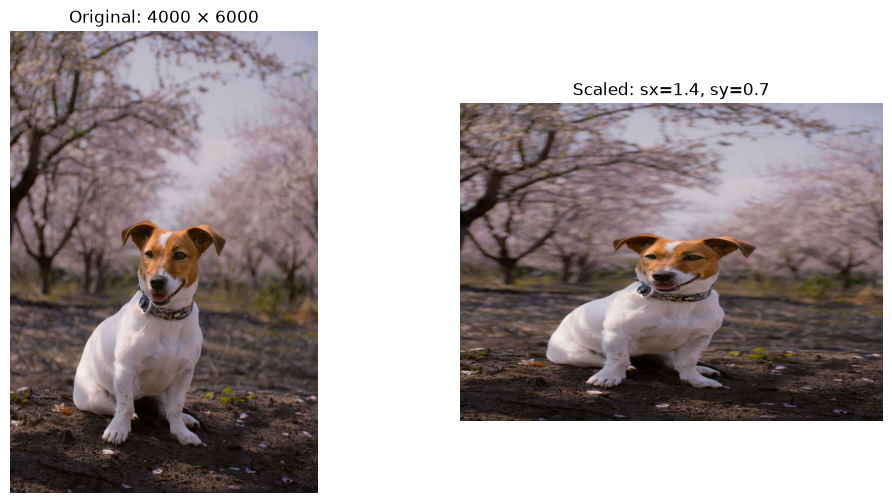

Original shape: (6000, 4000, 3)
Scaled shape: (4200, 5600, 3)


In [10]:
sx, sy = 1.4, 0.7

scaled = cv2.resize(img, None, fx=sx, fy=sy, interpolation=cv2.INTER_LINEAR)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Original: {W} × {H}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
plt.title(f"Scaled: sx={sx}, sy={sy}")
plt.axis("off")
plt.show()

print("Original shape:", img.shape)
print("Scaled shape:", scaled.shape)

### Experiment C1

Test:

1. `sx=2, sy=2`
2. `sx=0.5, sy=0.5`
3. `sx=2, sy=0.5`

**Question:** What is the difference between uniform and non-uniform scaling?

In [11]:
# code here

## 7. Reflection / Flipping

Reflection produces a mirror image.

Common image reflections are:

- horizontal flip,
- vertical flip,
- both axes.

OpenCV provides `cv2.flip()`.

For example:

```python
cv2.flip(image, 1)
```

performs a horizontal flip.

Reflection is useful in data augmentation and in applications where mirrored orientations are meaningful.

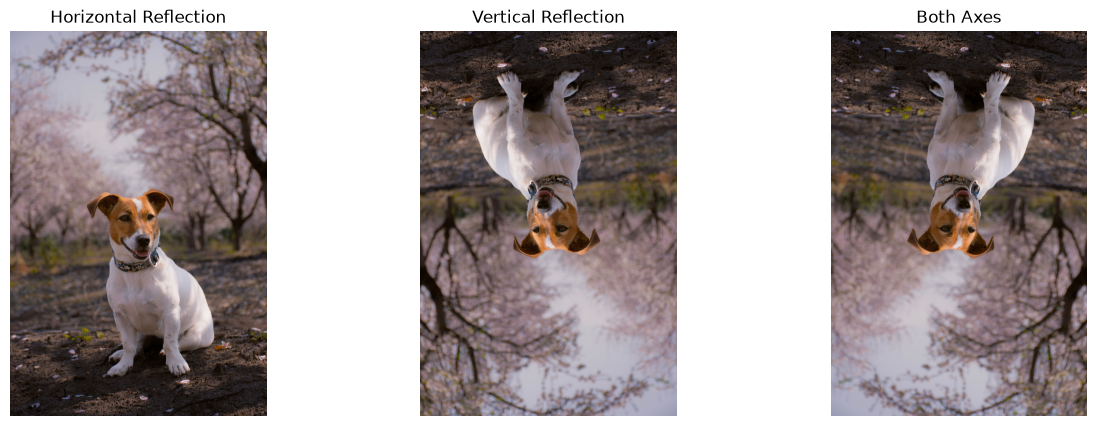

In [12]:
horizontal = cv2.flip(img, 1)
vertical = cv2.flip(img, 0)
both = cv2.flip(img, -1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
images = [horizontal, vertical, both]
titles = ["Horizontal Reflection", "Vertical Reflection", "Both Axes"]

for a, im, title in zip(ax, images, titles):
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    a.set_title(title)
    a.axis("off")
plt.show()

### Experiment D1

Use an image containing text or an asymmetric object.

1. Apply horizontal reflection.
2. Apply vertical reflection.
3. Apply both.

**Question:** Which transformation changes left and right? Which changes top and bottom?

In [13]:
# code here

## 8. Shearing

Shearing slants an image along one axis.

### Horizontal shear

$$
x'=x+sh_x y
$$

$$
y'=y
$$

Matrix:

$$
H_x=
\begin{bmatrix}
1&sh_x&0\\
0&1&0
\end{bmatrix}
$$

### Vertical shear

$$
x'=x
$$

$$
y'=y+sh_yx
$$

Matrix:

$$
H_y=
\begin{bmatrix}
1&0&0\\
sh_y&1&0
\end{bmatrix}
$$

Shearing changes the apparent shape and angles of objects while maintaining parallelism of lines.

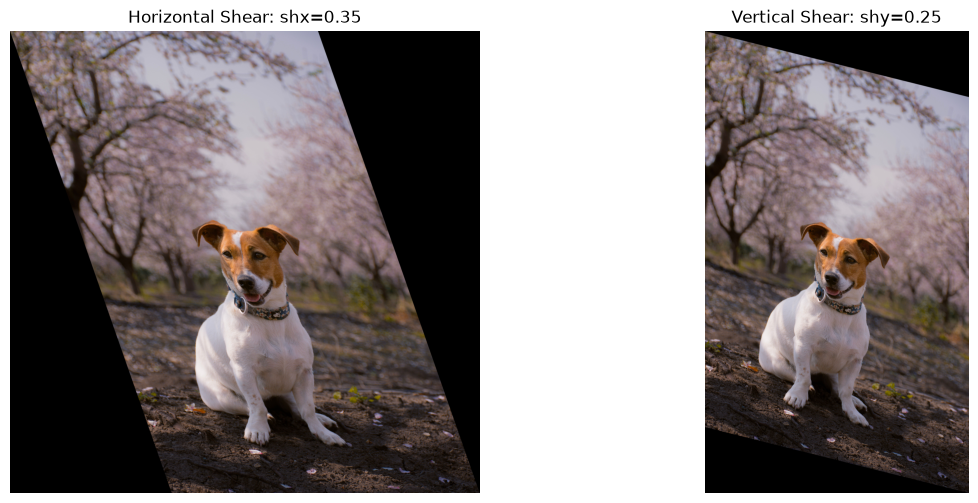

In [14]:
shx = 0.35
M_shear_x = np.float32([
    [1, shx, 0],
    [0, 1, 0]
])
# give extra widh for horizontal shift
new_W = int(W + abs(shx) * H)
sheared_x = cv2.warpAffine(img, M_shear_x, (new_W, H))
shy = 0.25
M_shear_y = np.float32([
    [1, 0, 0],
    [shy, 1, 0]
])
new_H = int(H + abs(shy) * W)
sheared_y = cv2.warpAffine(img, M_shear_y, (W, new_H))
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(cv2.cvtColor(sheared_x, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"Horizontal Shear: shx={shx}")
ax[1].imshow(cv2.cvtColor(sheared_y, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Vertical Shear: shy={shy}")
for a in ax:
    a.axis("off")
plt.show()

### Experiment E1

Try positive and negative shear values.

**Questions:**

1. What happens when `shx` becomes negative?
2. What happens when `shy` becomes negative?
3. Why can parts of an image be clipped after a transformation?

In [21]:
# code here

## 9. Affine Transformation

An affine transformation combines operations such as:

- translation,
- rotation,
- scaling,
- shearing,
- reflection.

Its general 2D form is:

\[
\begin{bmatrix}
x'\\y'
\end{bmatrix}
=
\begin{bmatrix}
a&b\\
c&d
\end{bmatrix}
\begin{bmatrix}
x\\y
\end{bmatrix}
+
\begin{bmatrix}
t_x\\t_y
\end{bmatrix}
\]

or:

\[
x'=ax+by+t_x
\]

\[
y'=cx+dy+t_y
\]

An affine transformation preserves **straight lines and parallelism**.

Three non-collinear points in the source image and their corresponding three points in the destination image are sufficient to determine an affine transformation.

OpenCV provides:

```python
cv2.getAffineTransform(src_points, dst_points)
```

followed by:

```python
cv2.warpAffine(...)
```

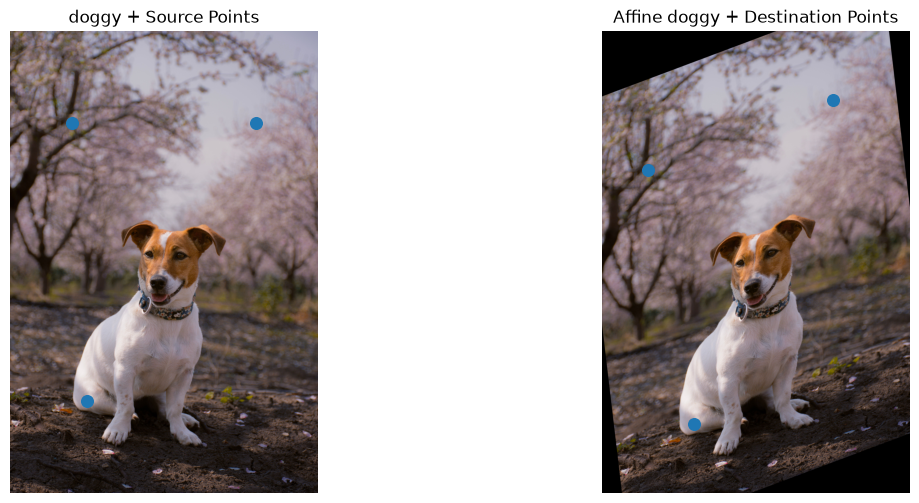

Affine transformation matrix:
[[ 1.00000000e+00  1.11111111e-01 -3.33333333e+02]
 [-3.75000000e-01  9.37500000e-01  9.75000000e+02]]


In [16]:
# Choose three non-collinear points dynamically from the Lena image
src_pts = np.float32([
    [0.20 * W, 0.20 * H],
    [0.80 * W, 0.20 * H],
    [0.25 * W, 0.80 * H]
])

# Move the three points to new positions
dst_pts = np.float32([
    [0.15 * W, 0.30 * H],
    [0.75 * W, 0.15 * H],
    [0.30 * W, 0.85 * H]
])

M_affine = cv2.getAffineTransform(src_pts, dst_pts)
affine_img = cv2.warpAffine(img, M_affine, (W, H))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].scatter(src_pts[:, 0], src_pts[:, 1], s=70)
ax[0].set_title("doggy + Source Points")

ax[1].imshow(cv2.cvtColor(affine_img, cv2.COLOR_BGR2RGB))
ax[1].scatter(dst_pts[:, 0], dst_pts[:, 1], s=70)
ax[1].set_title("Affine doggy + Destination Points")

for a in ax:
    a.axis("off")

plt.show()

print("Affine transformation matrix:")
print(M_affine)


### Experiment F1 — Build Your Own Affine Transformation

Select three non-collinear points from the image and create three destination points.

Try to produce:

- rotation + translation,
- scaling + translation,
- shearing + translation.

**Question:** Why must the three source points not be collinear?

In [17]:
# code here

## 10. Perspective Transformation

Perspective transformation is used when an image must be mapped between two different quadrilateral views.

Unlike an affine transformation, perspective transformation can make originally parallel lines appear to converge.

The supplied Lab #01 introduces the perspective transformation using a **3×3 transformation matrix** and `cv2.getPerspectiveTransform()` / `cv2.warpPerspective()`.

The transformation is commonly expressed in homogeneous coordinates:

\[
\begin{bmatrix}
x'\\y'\\w'
\end{bmatrix}
=
H
\begin{bmatrix}
x\\y\\1
\end{bmatrix}
\]

The final Cartesian coordinates are obtained by normalization:

\[
X=\frac{x'}{w'},\qquad
Y=\frac{y'}{w'}
\]

Four corresponding points are required for a general perspective mapping.

### Typical applications

- document/receipt scanning,
- perspective correction,
- bird's-eye views,
- image registration,
- planar object rectification.

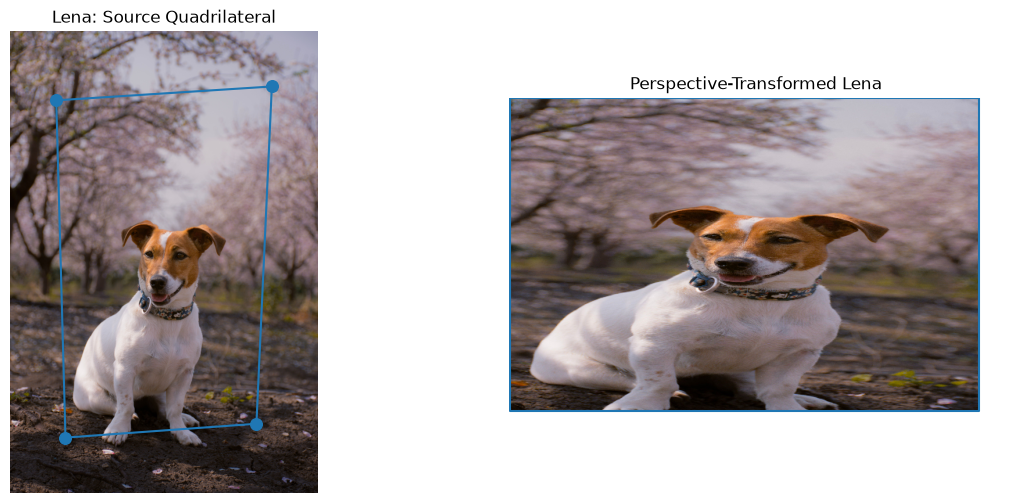

Perspective transformation matrix:
[[ 2.07464943e-01 -5.68397104e-03 -1.19363392e+02]
 [ 5.05923624e-03  7.86992305e-02 -7.38648492e+01]
 [-3.47707440e-06 -2.54208640e-05  1.00000000e+00]]


In [18]:
# Four corners of a quadrilateral selected from Lena
src_quad = np.float32([
    [0.15 * W, 0.15 * H],
    [0.85 * W, 0.12 * H],
    [0.80 * W, 0.85 * H],
    [0.18 * W, 0.88 * H]
])

# Rectangular destination
dst_quad = np.float32([
    [0, 0],
    [600, 0],
    [600, 400],
    [0, 400]
])

M_perspective = cv2.getPerspectiveTransform(src_quad, dst_quad)
perspective_img = cv2.warpPerspective(img, M_perspective, (600, 400))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].plot(
    np.r_[src_quad[:, 0], src_quad[0, 0]],
    np.r_[src_quad[:, 1], src_quad[0, 1]]
)
ax[0].scatter(src_quad[:, 0], src_quad[:, 1], s=70)
ax[0].set_title("Lena: Source Quadrilateral")

ax[1].imshow(cv2.cvtColor(perspective_img, cv2.COLOR_BGR2RGB))
ax[1].plot(
    np.r_[dst_quad[:, 0], dst_quad[0, 0]],
    np.r_[dst_quad[:, 1], dst_quad[0, 1]]
)
ax[1].set_title("Perspective-Transformed Lena")

for a in ax:
    a.axis("off")

plt.show()

print("Perspective transformation matrix:")
print(M_perspective)


### Experiment G1 — Document Rectification

Take a photograph of a page, card, poster or rectangular object from an angle.

1. Identify its four corners.
2. Store them in `src_quad`.
3. Define a rectangular `dst_quad`.
4. Compute the perspective matrix.
5. Apply `cv2.warpPerspective()`.

**Observation:** Explain how the result differs from a simple rotation.

In [19]:
# code here

# Part H — Comparing Affine and Perspective Transformations

## 11. Affine vs Perspective

| Property | Affine | Perspective |
|---|---|---|
| Matrix | 2×3 | 3×3 |
| Corresponding points | 3 | 4 |
| Straight lines remain straight | Yes | Yes |
| Parallelism preserved | Yes | Not necessarily |
| Models viewpoint effects | Limited | Yes |
| OpenCV function | `warpAffine()` | `warpPerspective()` |
| Common use | rotation, scaling, shear, alignment | document rectification, viewpoint correction |

### Key idea

Use an **affine transformation** when the geometric relationship can be adequately modeled using linear transformation + translation.

Use a **perspective transformation** when the viewpoint causes projective distortion and a quadrilateral must be mapped to another quadrilateral.

# Mini Computer Vision Task

## Challenge: Build a Simple Document Scanner

Create a small document-scanning pipeline:

**Input image → Find/select four corners → Perspective transform → Rectified document → Resize**

You may initially select the four points manually.

## For view ,optional: in next labs
Try automatically detecting the document boundary using edge detection and contours.
